**This notebook on multi-objective optimization provides an overview of the Non-dominated Sorting Genetic Algorithm II (NSGA-II) alongside practical implementation steps ranging from benchmark problem solving to real-world portfolio optimization.**

# **Outline**

1. Installation and library setup
2. Introduction to NSGA-II
3. Using NSGA-II to solve benchmark problem
4. Parameter experiment with NSGA-II
5. Defining a custom multi-objective problem
6. Constrained multi-objective optimization
7. Portfolio Optimization Problem
8. Introduction to NSGA-III

**References**:
- K. Deb, A. Pratap, S. Agarwal and T. Meyarivan, "A fast and elitist multiobjective genetic algorithm: NSGA-II," in IEEE Transactions on Evolutionary Computation, vol. 6, no. 2, pp. 182-197, April 2002, doi: 10.1109/4235.996017.
- K. Deb and H. Jain, "An Evolutionary Many-Objective Optimization Algorithm Using Reference-Point-Based Nondominated Sorting Approach, Part I: Solving Problems With Box Constraints," in IEEE Transactions on Evolutionary Computation, vol. 18, no. 4, pp. 577-601, Aug. 2014, doi: 10.1109/TEVC.2013.2281535.
- Blank, J., & Deb, K. (2020). pymoo: Multi-objective Optimization in Python. IEEE Access.
- Markowitz, H. (1952). Portfolio Selection. The Journal of Finance, 7(1), 77–91.

# 1. Installation

In this tutorial, we will use `pymoo`, a Python library for optimization.
pymoo supports single-objective, multi-objective, many-objective, constrained, and engineering optimization problems. For more information, readers are directed to pymoo's documentation [https://pymoo.org/].




In [ ]:
# Install pymoo
!pip install -U pymoo

# Install basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 2. Non-Dominated Sorting Genetic Algorithm II

NSGA-II, or Non-dominated Sorting Genetic Algorithm II, is one of the most widely used evolutionary algorithms for solving multi-objective optimization problems. The main idea of NSGA-II is to evolve a population of candidate solutions while maintaining both convergence toward the Pareto front and diversity among solutions.


NSGA-II ranks solutions using `non-dominated sorting`. Solutions that are not dominated by any other solution are placed in the first front, called $F_1$. After removing $F_1$, the next set of non-dominated solutions forms $F_2$, and so on. **A lower rank indicates a better solution**. The algorithm also uses `crowding distance` to preserve diversity among solutions. In pymoo, NSGA-II uses non-dominated rank and crowding distance to maintain diversity in the objective space, and the crowding distance is based on the Manhattan distance in objective space.

For a solution (i), the crowding distance can be expressed as:

$$
CD_i =
\sum_{m=1}^{M}
\frac{
f_m^{i+1} - f_m^{i-1}
}{
f_m^{\max} - f_m^{\min}
}
$$

where $CD_i$ is the crowding distance of solution $i$, $M$ is the number of objectives, $f_m^{i+1}$ and $f_m^{i-1}$ are the neighboring objective values after sorting based on objective $m$, and $f_m^{\max}$ and $f_m^{\min}$ are the maximum and minimum values of objective $m$.

If two solutions have the same rank, the **solution with a larger crowding distance is preferred** because it helps maintain diversity.

The basic workflow of NSGA-II consists of:
1. initializing a population,
2. evaluating objective functions,
3. sorting solutions into non-dominated fronts,
4. calculating crowding distance,
5. selecting parents,
6. applying `crossover` and `mutation`,
7. combining parent and offspring populations, and
8. selecting the best individuals for the next generation.

Through this process, NSGA-II gradually approximates the Pareto front.



In [ ]:
from pymoo.algorithms.moo.nsga2 import NSGA2
algorithm = NSGA2(pop_size=100)

# 3. First Example: Solving ZDT1 with NSGA-II

The benchmark problem used here is **ZDT1**, which is one of the well-known Zitzler-Deb-Thiele test problems for evaluating multi-objective evolutionary algorithms. In `pymoo`, ZDT1 is implemented as a 30-variable problem with two objective functions and a convex Pareto-optimal front.

The ZDT1 problem can be written as:

$$
\min_{\mathbf{x}} \quad \mathbf{F}(\mathbf{x}) =
\left[
f_1(\mathbf{x}), f_2(\mathbf{x})
\right]
$$

where:

$$
f_1(\mathbf{x}) = x_1
$$

$$
f_2(\mathbf{x}) = g(\mathbf{x})h(f_1,g)
$$

$$
g(\mathbf{x}) =
1 + \frac{9}{n-1}
\sum_{i=2}^{n} x_i
$$

$$
h(f_1,g) =
1 - \sqrt{\frac{f_1}{g}}
$$

with the variable bounds:

$$
0 \leq x_i \leq 1,
\quad i = 1,2,\dots,n
$$

For ZDT1, the Pareto-optimal solution occurs when:

$$
0 \leq x_1^* \leq 1
$$

and

$$
x_i^* = 0,
\quad i = 2,3,\dots,n
$$

n_gen  |  n_eval  | n_nds  |      igd      |       gd      |       hv     
     1 |       50 |      6 |  2.4417147062 |  2.8471075545 |  0.000000E+00
     2 |      100 |     10 |  2.1605212986 |  2.4869933290 |  0.000000E+00
     3 |      150 |     13 |  1.9336568097 |  2.2454521864 |  0.000000E+00
     4 |      200 |     15 |  1.9280184199 |  2.3524979283 |  0.000000E+00
     5 |      250 |     16 |  1.5697922430 |  2.2300135912 |  0.000000E+00
     6 |      300 |     14 |  1.4747353759 |  2.1670820777 |  0.000000E+00
     7 |      350 |     13 |  1.4637480324 |  1.9975349494 |  0.000000E+00
     8 |      400 |     12 |  1.3171061548 |  1.9477859948 |  0.000000E+00
     9 |      450 |     12 |  1.2692626414 |  1.8648616556 |  0.000000E+00
    10 |      500 |     12 |  1.1509326966 |  1.6289137424 |  0.000000E+00
    11 |      550 |     18 |  1.1138470728 |  1.4386789175 |  0.000000E+00
    12 |      600 |     12 |  1.1023726921 |  1.1496505609 |  0.000000E+00
    13 |      650 |     1

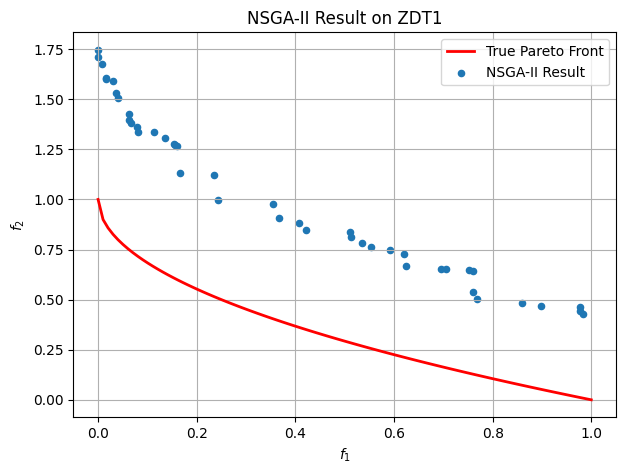

In [ ]:
from pymoo.problems import get_problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter

problem = get_problem("zdt1")

algorithm = NSGA2(pop_size=50)

res = minimize(
    problem,
    algorithm,
    termination=("n_gen", 50),
    seed=1,
    save_history=True,
    verbose=True)

X = res.X
F = res.F
pf = problem.pareto_front()

plt.figure(figsize=(7, 5))
plt.plot(pf[:, 0], pf[:, 1], label="True Pareto Front", linewidth=2, color="red")
plt.scatter(F[:, 0], F[:, 1], label="NSGA-II Result", s=20)
plt.xlabel("$f_1$")
plt.ylabel("$f_2$")
plt.title("NSGA-II Result on ZDT1")
plt.legend()
plt.grid(True)
plt.show()

From the plot, a good optimization result should show points that are close to the true Pareto front and well distributed along the curve. Closeness to the true Pareto front indicates good convergence, while a well-spread distribution of points indicates good diversity.

# 4. Parameter Experiment with NSGA-II

For a population-based evolutionary algorithm such as NSGA-II, the approximate number of function evaluations can be written as:

$$
N_{\mathrm{eval}} \approx P \times G
$$

where:

$$
P = \text{population size}
$$

and

$$
G = \text{number of generations}
$$

If the number of offspring is explicitly defined, the approximate number of evaluations can be written as:

$$
N_{\mathrm{eval}} \approx P + N_{\mathrm{offspring}}(G-1)
$$

where:

$$
N_{\mathrm{offspring}} = \text{number of offspring generated in each generation}
$$

In this experiment, several parameters can be edited:

| Parameter | Meaning |
|---|---|
| `pop_size` | Number of candidate solutions in each generation |
| `n_gen` | Number of generations used as the stopping criterion |
| `n_offsprings` | Number of offspring generated per generation |
| `crossover_prob` | Probability of applying crossover |
| `crossover_eta` | Distribution index for Simulated Binary Crossover, SBX |
| `mutation_eta` | Distribution index for Polynomial Mutation |


In general, a larger `pop_size` may improve the diversity of solutions, while a larger `n_gen` may improve convergence. However, both settings increase computational cost.

To compare the quality of each experiment, we use the Inverted Generational Distance, or IGD. IGD measures how far the obtained solution set is from the reference Pareto front. A smaller IGD value indicates a better approximation of the Pareto front.

In [ ]:
# Import the required modules for the parameter experiment
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM

# Import the performance evaluation matrics
from pymoo.indicators.igd import IGD

# Define the benchmark problem and its true Pareto front.
problem = get_problem("zdt1")
pf = problem.pareto_front()

igd = IGD(pf)

In [ ]:
experiment_settings = [
    {
        "name": "Small population, short run",
        "pop_size": 50,
        "n_gen": 100,
        "n_offsprings": 50,
        "crossover_prob": 0.9,
        "crossover_eta": 15,
        "mutation_eta": 20,
        "seed": 1,
    },
    {
        "name": "Small population, long run",
        "pop_size": 50,
        "n_gen": 200,
        "n_offsprings": 50,
        "crossover_prob": 0.9,
        "crossover_eta": 15,
        "mutation_eta": 20,
        "seed": 1,
    },
    {
        "name": "Large population, short run",
        "pop_size": 100,
        "n_gen": 100,
        "n_offsprings": 100,
        "crossover_prob": 0.9,
        "crossover_eta": 15,
        "mutation_eta": 20,
        "seed": 1,
    },
    {
        "name": "Large population, long run",
        "pop_size": 50,
        "n_gen": 50,
        "n_offsprings": 100,
        "crossover_prob": 0.9,
        "crossover_eta": 100,
        "mutation_eta": 20,
        "seed": 1,
    }
]

In [ ]:
# Run NSGA-II for each parameter setting and store the results.

results = []
fronts = {}

# Loop through each dictionary inside experiment_settings.
for setting in experiment_settings:
    algorithm = NSGA2(
        pop_size=setting["pop_size"],
        n_offsprings=setting["n_offsprings"],
        sampling=FloatRandomSampling(),
        crossover=SBX(
            prob=setting["crossover_prob"],
            eta=setting["crossover_eta"]
        ),
        mutation=PM(
            eta=setting["mutation_eta"]
        ),
    )

    # Run the optimization using the current NSGA-II algorithm.
    res_exp = minimize(
        problem,
        algorithm,
        termination=("n_gen", setting["n_gen"]),
        seed=setting["seed"],
        verbose=False
    )

    # Extract the objective values of the final solutions.
    F_exp = res_exp.F

    igd_value = igd.do(F_exp)

    # Creating table
    results.append({
        "experiment": setting["name"],
        "pop_size": setting["pop_size"],
        "n_gen": setting["n_gen"],
        "crossover_prob": setting["crossover_prob"],
        "crossover_eta": setting["crossover_eta"],
        "mutation_eta": setting["mutation_eta"],
        "seed": setting["seed"],
        "n_solutions": len(F_exp),
        "IGD": igd_value
    })

    fronts[setting["name"]] = F_exp

results_df = pd.DataFrame(results)
results_df

,experiment,pop_size,n_gen,crossover_prob,crossover_eta,mutation_eta,seed,n_solutions,IGD
0,"Small population, short run",50,100,0.9,15,20,1,50,0.051662
1,"Small population, long run",50,200,0.9,15,20,1,50,0.011466
2,"Large population, short run",100,100,0.9,15,20,1,100,0.015245
3,"Large population, long run",50,50,0.9,100,20,1,50,0.113266


A smaller Inverted Generational Distance (IGD) indicates a better approximation of the true Pareto front. As shown in the table, increasing both the population size and the number of generations yields a smaller IGD, thereby improving the approximation closer to the true Pareto front.

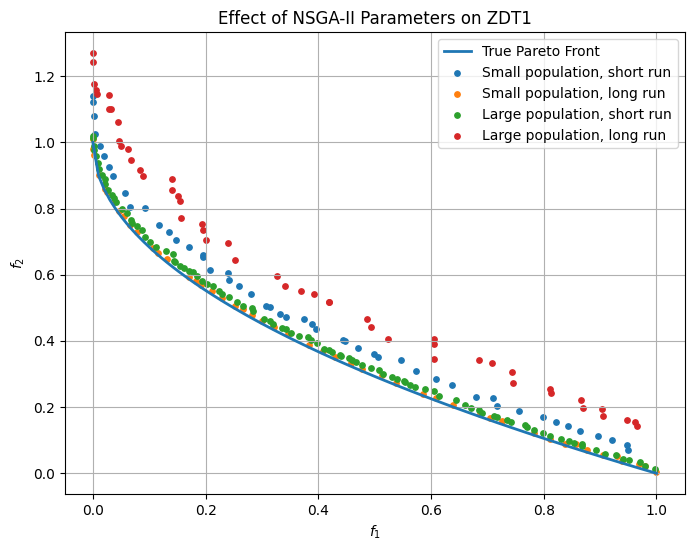

In [ ]:
# Sort the experiment results based on IGD.
# Smaller IGD means a better approximation of the true Pareto front.

# Visualize the Pareto front approximation from each experiment.

plt.figure(figsize=(8, 6))

plt.plot(
    pf[:, 0],
    pf[:, 1],
    label="True Pareto Front",
    linewidth=2
)

for name, F_exp in fronts.items():
    plt.scatter(
        F_exp[:, 0],
        F_exp[:, 1],
        s=15,
        label=name
    )

plt.xlabel("$f_1$")
plt.ylabel("$f_2$")
plt.title("Effect of NSGA-II Parameters on ZDT1")
plt.legend()
plt.grid(True)
plt.show()

# 5. Defining a Custom Multi-objective Problem

We will define our own multi-objective optimization problem instead of using a built-in benchmark problem. This is useful because real optimization problems usually have objective functions that come from a specific application, model, or engineering system.

The custom problem used in this section has two decision variables:

$$
\mathbf{x} = [x_1, x_2]
$$

and two objective functions:

$$
\min_{\mathbf{x}} \quad \mathbf{F}(\mathbf{x}) =
\left[
f_1(\mathbf{x}), f_2(\mathbf{x})
\right]
$$

where:

$$
f_1(\mathbf{x}) = x_1^2 + x_2^2
$$

and:

$$
f_2(\mathbf{x}) = (x_1 - 1)^2 + x_2^2
$$

The variable bounds are:

$$
-2 \leq x_1 \leq 2
$$

$$
-2 \leq x_2 \leq 2
$$

The first objective, $f_1$, is minimized near the point $(0,0)$. The second objective, $f_2$, is minimized near the point $(1,0)$. Because these two objectives have different preferred locations, the optimizer must find a set of trade-off solutions between them.

In `pymoo`, a custom problem can be defined by creating a class that inherits from `ElementwiseProblem`. The main editable parts of the problem definition are:

| Parameter or Component | Meaning |
|---|---|
| `n_var` | Number of decision variables |
| `n_obj` | Number of objective functions |
| `xl` | Lower bound of each decision variable |
| `xu` | Upper bound of each decision variable |
| `_evaluate()` | Function where the objective values are calculated |
| `out["F"]` | Output container for the objective function values |

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      200 |      7 |             - |             -
     2 |      400 |     16 |  0.0862117143 |             f
     3 |      600 |     25 |  0.0090114967 |         ideal
     4 |      800 |     44 |  0.0142504386 |         ideal
     5 |     1000 |     64 |  0.0079079341 |             f
     6 |     1200 |     89 |  0.0028029981 |         ideal
     7 |     1400 |    111 |  0.0168969060 |         nadir
     8 |     1600 |    150 |  0.0029555034 |             f
     9 |     1800 |    185 |  0.0011453032 |             f
    10 |     2000 |    200 |  0.0300731582 |         nadir
    11 |     2200 |    200 |  0.0502541969 |         nadir
    12 |     2400 |    200 |  0.0007853125 |             f
    13 |     2600 |    200 |  0.0013285533 |             f
    14 |     2800 |    200 |  0.0017285105 |             f
    15 |     3000 |    200 |  0.0224379465 |         nadir
    16 |     3200 |    200 |  0.0328826714 |         nad

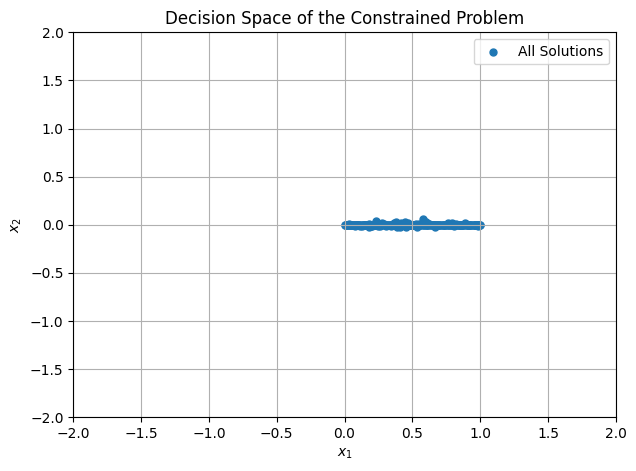

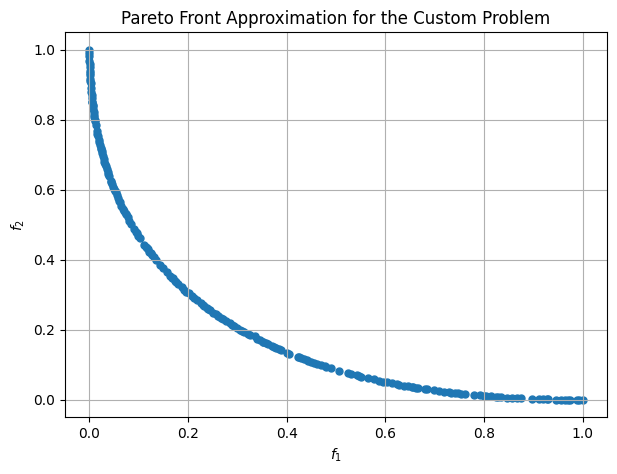

In [ ]:
# Import the required modules for defining and solving a custom problem
from pymoo.core.problem import ElementwiseProblem

# Define a custom bi-objective optimization problem
class BiObjectiveProblem(ElementwiseProblem):
    def __init__(self):
        super().__init__(
            n_var=2,
            n_obj=2,
            xl=np.array([-2, -2]),
            xu=np.array([2, 2])
        )

    def _evaluate(self, x, out, *args, **kwargs):
        f1 = x[0]**2 + x[1]**2
        f2 = (x[0] - 1)**2 + x[1]**2

        out["F"] = [f1, f2]

# Create the custom problem and define the NSGA-II algorithm
problem_custom = BiObjectiveProblem()
algorithm = NSGA2(
    pop_size=200
)

# Run the optimization process
res_custom = minimize(
    problem_custom,
    algorithm,
    termination=("n_gen", 200),
    seed=1,
    verbose=True
)

# Extract the decision variables and objective function values
X_custom = res_custom.X
F_custom = res_custom.F

# Visualize the decision variables design space
plt.figure(figsize=(7, 5))
plt.scatter(X_custom[:, 0], X_custom[:, 1], s=25, label="All Solutions")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Decision Space of the Constrained Problem")
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.legend()
plt.grid(True)
plt.show()


# Visualize the Pareto front approximation in the objective space
plt.figure(figsize=(7, 5))
plt.scatter(F_custom[:, 0], F_custom[:, 1], s=25)
plt.xlabel("$f_1$")
plt.ylabel("$f_2$")
plt.title("Pareto Front Approximation for the Custom Problem")
plt.grid(True)
plt.show()

## 5.1. Challenge #1: Solve this Multiobjective Problem

$$
\mathbf{x} = [x_1, x_2, x_3, x_4]
$$

$$
\min_{\mathbf{x}} \ \mathbf{F}(\mathbf{x}) =
\left[ f_1(\mathbf{x}), f_2(\mathbf{x}), f_3(\mathbf{x}) \right]
$$

$$
f_1(\mathbf{x}) = x_1^2 + x_2^2 + x_3^2 + x_4^2
$$

$$
f_2(\mathbf{x}) =
(x_1 - 1)^2 + (x_2 + 1)^2 + (x_3 - 0.5)^2 + x_4^2
$$

$$
f_3(\mathbf{x}) =
(x_1 + 1)^2 + (x_2 - 1)^2 + (x_3 + 0.5)^2 + (x_4 - 1)^2
$$

$$
-3 \leq x_1 \leq 3
$$

$$
-3 \leq x_2 \leq 3
$$

$$
-3 \leq x_3 \leq 3
$$

$$
-3 \leq x_4 \leq 3
$$

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      300 |      5 |             - |             -
     2 |      600 |     12 |  0.0087884595 |         ideal
     3 |      900 |     15 |  0.0392434121 |         ideal
     4 |     1200 |     25 |  0.0259951211 |         ideal
     5 |     1500 |     41 |  0.0094144729 |         ideal
     6 |     1800 |     62 |  0.0047395094 |         ideal
     7 |     2100 |     89 |  0.0163277927 |         ideal
     8 |     2400 |    117 |  0.0039200595 |         ideal
     9 |     2700 |    158 |  0.0993610546 |         nadir
    10 |     3000 |    194 |  0.2036633388 |         nadir
    11 |     3300 |    240 |  0.0049558146 |             f
    12 |     3600 |    275 |  0.0032985672 |             f
    13 |     3900 |    300 |  0.0029352100 |         ideal
    14 |     4200 |    300 |  0.1215201115 |         nadir
    15 |     4500 |    300 |  0.0023101331 |             f
    16 |     4800 |    300 |  0.0064340176 |         nad

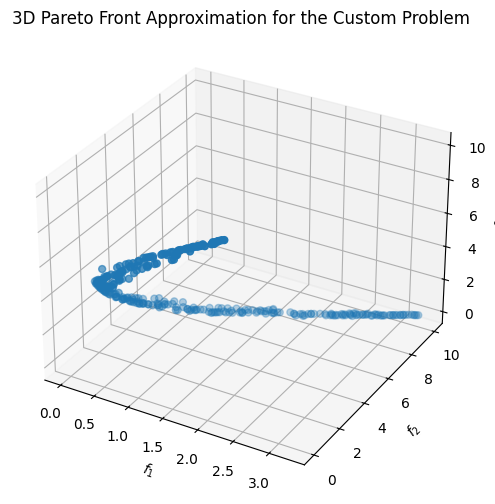

In [ ]:
# Import the required modules for defining and solving a custom problem
from pymoo.core.problem import ElementwiseProblem

# Define a custom bi-objective optimization problem
class MyMultiObjectiveProblem(ElementwiseProblem):
    def __init__(self):
        super().__init__(
            n_var=4,
            n_obj=3,
            xl=np.array([-3, -3, -3, -3]),
            xu=np.array([3, 3, 3, 3])
        )

    def _evaluate(self, x, out, *args, **kwargs):
        f1 = x[0]**2 + x[1]**2 + x[2]**2 + x[3]**2

        f2 = (x[0] - 1)**2 + (x[1] + 1)**2 + (x[2] - 0.5)**2 + x[3]**2

        f3 = (x[0] + 1)**2 + (x[1] - 1)**2 + (x[2] + 0.5)**2 + (x[3] - 1)**2

        out["F"] = [f1, f2, f3]

# Create the custom problem and define the NSGA-II algorithm
problem_custom = MyMultiObjectiveProblem()
algorithm = NSGA2(
    pop_size=300
)

# Run the optimization process
res_challenge = minimize(
    problem_custom,
    algorithm,
    termination=("n_gen", 500),
    seed=1,
    verbose=True
)

# Extract the decision variables and objective function values
X_challenge = res_challenge.X
F_challenge = res_challenge.F


# Visualize the Pareto front approximation in 3D objective space
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1, projection="3d")

ax.scatter(
    F_challenge[:, 0],
    F_challenge[:, 1],
    F_challenge[:, 2],
    s=25
)

ax.set_xlabel("$f_1$")
ax.set_ylabel("$f_2$")
ax.set_zlabel("$f_3$")

ax.set_title("3D Pareto Front Approximation for the Custom Problem")

plt.show()

# 6. Constrained Multi-objective Optimization

We extend the custom multi-objective problem by adding a constraint. Constraints are important because real optimization problems usually have limitations, such as physical limits, design requirements, cost limits, safety limits, or operational boundaries.

The constrained problem used in this section has two decision variables:

$$
\mathbf{x} = [x_1, x_2]
$$

and two objective functions:

$$
\min_{\mathbf{x}} \quad \mathbf{F}(\mathbf{x}) =
\left[
f_1(\mathbf{x}), f_2(\mathbf{x})
\right]
$$

where:

$$
f_1(\mathbf{x}) = x_1^2 + x_2^2
$$

and:

$$
f_2(\mathbf{x}) = (x_1 - 1)^2 + x_2^2
$$

The variable bounds are:

$$
-2 \leq x_1 \leq 2
$$

$$
-2 \leq x_2 \leq 2
$$

In this constrained version, we add one inequality constraint:

$$
g_1(\mathbf{x}) = x_1 + x_2 - 0.6 \leq 0
$$

This constraint means that the sum of $x_1$ and $x_2$ must not be greater than 0.6:

$$
x_1 + x_2 \leq 0.6
$$

In `pymoo`, inequality constraints must be written in the form:

$$
g_i(\mathbf{x}) \leq 0
$$

Therefore, the constraint value is stored in:

$$
\texttt{out["G"]}
$$

The main editable parts in this section are:

| Parameter or Component | Meaning |
|---|---|
| `limit` | Constraint limit in $$x_1 + x_2 \leq \text{limit}$$ |
| `n_ieq_constr` | Number of inequality constraints |
| `xl` | Lower bound of each decision variable |
| `xu` | Upper bound of each decision variable |
| `out["F"]` | Objective function values |
| `out["G"]` | Inequality constraint values |
| `pop_size` | Number of candidate solutions in each generation |
| `n_gen` | Number of generations |
| `seed` | Random seed for reproducibility |

A feasible solution must satisfy all inequality constraints. If:

$$
g_1(\mathbf{x}) \leq 0
$$

then the solution is feasible. If:

$$
g_1(\mathbf{x}) > 0
$$

then the solution is infeasible.

n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      200 |      4 |  0.000000E+00 |  0.3524982891 |             - |             -
     2 |      400 |      7 |  0.000000E+00 |  0.000000E+00 |  0.0316142320 |         ideal
     3 |      600 |     10 |  0.000000E+00 |  0.000000E+00 |  0.0294416512 |             f
     4 |      800 |     19 |  0.000000E+00 |  0.000000E+00 |  0.0327535175 |             f
     5 |     1000 |     29 |  0.000000E+00 |  0.000000E+00 |  0.0285841890 |         ideal
     6 |     1200 |     44 |  0.000000E+00 |  0.000000E+00 |  0.0195200312 |             f
     7 |     1400 |     56 |  0.000000E+00 |  0.000000E+00 |  0.2584879150 |         nadir
     8 |     1600 |     68 |  0.000000E+00 |  0.000000E+00 |  0.0030963448 |         ideal
     9 |     1800 |     84 |  0.000000E+00 |  0.000000E+00 |  0.0113006770 |         nadir
    10 |     2000 |    107 |  0.000000E+00 |  0.000000E+00 |  0.0210702033 |         nadir

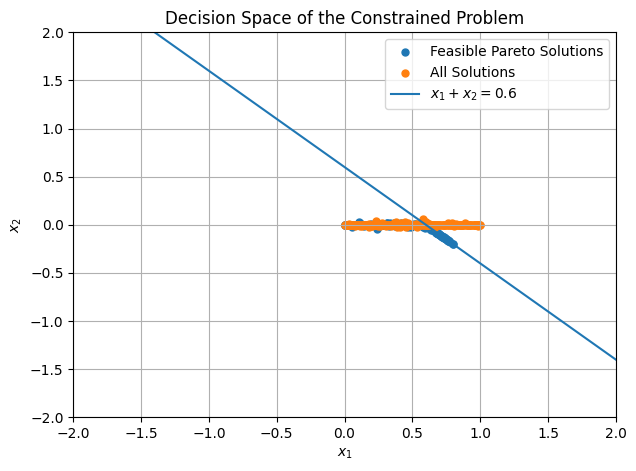

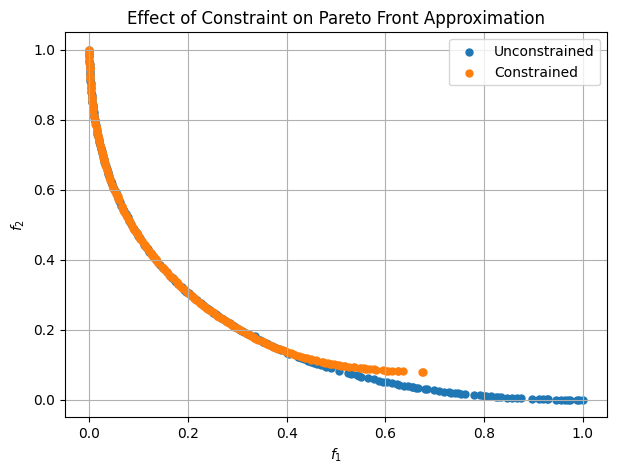

In [ ]:
# Define a constrained bi-objective optimization problem
class ConstrainedBiObjectiveProblem(ElementwiseProblem):

    def __init__(self, limit=0.6):
        self.limit = limit

        super().__init__(
            n_var=2,
            n_obj=2,
            n_ieq_constr=1,
            xl=np.array([-2, -2]),
            xu=np.array([2, 2])
        )

    def _evaluate(self, x, out, *args, **kwargs):
        f1 = x[0]**2 + x[1]**2
        f2 = (x[0] - 1)**2 + x[1]**2

        g1 = x[0] + x[1] - self.limit

        out["F"] = [f1, f2]
        out["G"] = [g1]

# Edit these values to change the constrained optimization experiment
constraint_limit = 0.6
pop_size = 200
n_gen = 200
seed = 1


# Create the constrained problem and define the NSGA-II algorithm
problem_constrained = ConstrainedBiObjectiveProblem(
    limit=constraint_limit
)

algorithm = NSGA2(
    pop_size=pop_size
)

# Create the constrained problem and define the NSGA-II algorithm
problem_constrained = ConstrainedBiObjectiveProblem(
    limit=constraint_limit
)

algorithm = NSGA2(
    pop_size=pop_size
)

# Run the constrained optimization process
res_constrained = minimize(
    problem_constrained,
    algorithm,
    termination=("n_gen", n_gen),
    seed=seed,
    verbose=True
)

# Extract the decision variables, objective values, and constraint values
X_constrained = res_constrained.X
F_constrained = res_constrained.F

# Visualize the decision variables and the constraint boundary in the design space
x1_line = np.linspace(-2, 2, 200)
x2_line = constraint_limit - x1_line

plt.figure(figsize=(7, 5))
plt.scatter(X_constrained[:, 0], X_constrained[:, 1], s=25, label="Feasible Pareto Solutions")
plt.scatter(X_custom[:, 0], X_custom[:, 1], s=25, label="All Solutions")
plt.plot(x1_line, x2_line, label="$x_1 + x_2 = 0.6$")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Decision Space of the Constrained Problem")
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.legend()
plt.grid(True)
plt.show()

# Compare the unconstrained and constrained Pareto front approximations
plt.figure(figsize=(7, 5))
plt.scatter(F_custom[:, 0], F_custom[:, 1], s=25, label="Unconstrained")
plt.scatter(F_constrained[:, 0], F_constrained[:, 1], s=25, label="Constrained")
plt.xlabel("$f_1$")
plt.ylabel("$f_2$")
plt.title("Effect of Constraint on Pareto Front Approximation")
plt.legend()
plt.grid(True)
plt.show()

## 6.1 Challenge #2: Solve this constrainted multi-objective problem
$$
\mathbf{x} = [x_1, x_2]
$$

$$
\min_{\mathbf{x}} \ \mathbf{F}(\mathbf{x}) =
\left[ f_1(\mathbf{x}), f_2(\mathbf{x}) \right]
$$

where:

$$
f_1(\mathbf{x}) = x_1^2 + x_2^2
$$

$$
f_2(\mathbf{x}) = (x_1 - 1)^2 + x_2^2
$$

subject to:

$$
- x_2 \geq x_1 - 0.8
$$

$$
\frac{5}{4}x_1 - x_2 \geq 0.3
$$

with variable bounds:

$$
-2 \leq x_1 \leq 2
$$

$$
-2 \leq x_2 \leq 2
$$

n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      200 |      6 |  0.000000E+00 |  1.2988664707 |             - |             -
     2 |      400 |      7 |  0.000000E+00 |  0.1008433795 |  0.0861402660 |         ideal
     3 |      600 |     10 |  0.000000E+00 |  0.000000E+00 |  0.0077227578 |         ideal
     4 |      800 |     14 |  0.000000E+00 |  0.000000E+00 |  0.0384466307 |         ideal
     5 |     1000 |     22 |  0.000000E+00 |  0.000000E+00 |  0.0250720268 |             f
     6 |     1200 |     31 |  0.000000E+00 |  0.000000E+00 |  0.0230459549 |             f
     7 |     1400 |     42 |  0.000000E+00 |  0.000000E+00 |  0.0031404232 |         ideal
     8 |     1600 |     61 |  0.000000E+00 |  0.000000E+00 |  0.0037614814 |         ideal
     9 |     1800 |     74 |  0.000000E+00 |  0.000000E+00 |  0.0030695661 |             f
    10 |     2000 |     96 |  0.000000E+00 |  0.000000E+00 |  0.0020085216 |             f

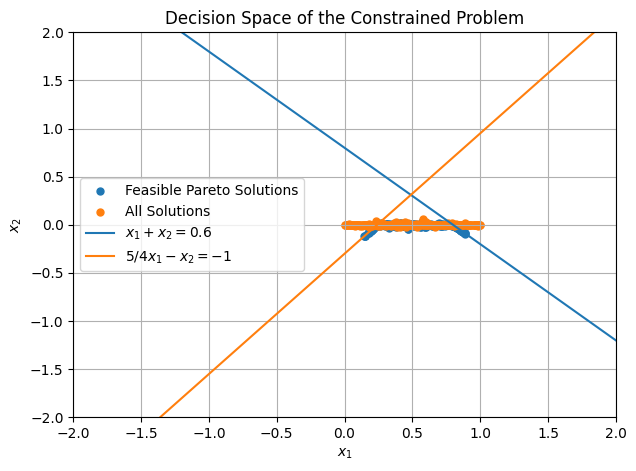

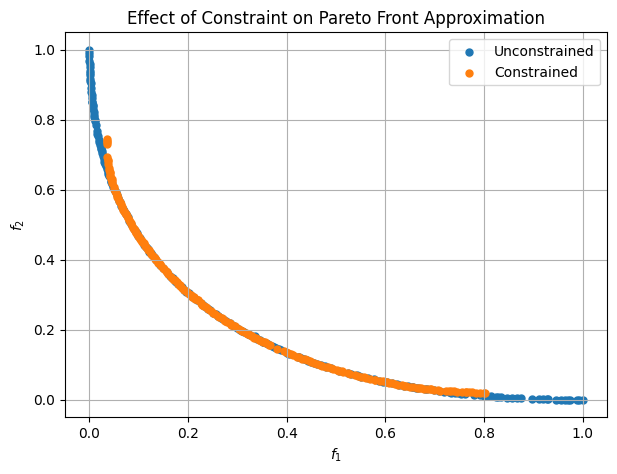

In [ ]:
# Define a constrained bi-objective optimization problem
class ChallengeConstrainedBiObjectiveProblem(ElementwiseProblem):

    def __init__(self):
        super().__init__(
            n_var=2,
            n_obj=2,
            n_ieq_constr=2,
            xl=np.array([-2, -2]),
            xu=np.array([2, 2])
        )

    def _evaluate(self, x, out, *args, **kwargs):
        f1 = x[0]**2 + x[1]**2
        f2 = (x[0] - 1)**2 + x[1]**2

        g1 = x[0] + x[1] - 0.8
        g2 = -(5/4)*x[0] + x[1] + 0.3

        out["F"] = [f1, f2]
        out["G"] = [g1, g2]

# Edit these values to change the constrained optimization experiment
pop_size = 200
n_gen = 200
seed = 1


# Create the constrained problem and define the NSGA-II algorithm
problem_constrained = ChallengeConstrainedBiObjectiveProblem()
algorithm = NSGA2(pop_size=pop_size)


# Run the constrained optimization process
res_constrained = minimize(
    problem_constrained,
    algorithm,
    termination=("n_gen", n_gen),
    seed=seed,
    verbose=True
)

# Extract the decision variables, objective values, and constraint values
X_constrained = res_constrained.X
F_constrained = res_constrained.F

# Visualize the decision variables and the constraint boundary in the design space
x1_line = np.linspace(-2, 2, 200)
x2_line = 0.8 - x1_line
x2_line2 = (5/4) * x1_line - 0.3

plt.figure(figsize=(7, 5))
plt.scatter(X_constrained[:, 0], X_constrained[:, 1], s=25, label="Feasible Pareto Solutions")
plt.scatter(X_custom[:, 0], X_custom[:, 1], s=25, label="All Solutions")
plt.plot(x1_line, x2_line, label="$x_1 + x_2 = 0.6$")
plt.plot(x1_line, x2_line2, label="$5/4x_1 - x_2 = -1$")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Decision Space of the Constrained Problem")
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.legend()
plt.grid(True)
plt.show()

# Compare the unconstrained and constrained Pareto front approximations
plt.figure(figsize=(7, 5))
plt.scatter(F_custom[:, 0], F_custom[:, 1], s=25, label="Unconstrained")
plt.scatter(F_constrained[:, 0], F_constrained[:, 1], s=25, label="Constrained")
plt.xlabel("$f_1$")
plt.ylabel("$f_2$")
plt.title("Effect of Constraint on Pareto Front Approximation")
plt.legend()
plt.grid(True)
plt.show()

# 7. Real-World Problem: Portfolio Optimization

In this section, we apply multi-objective optimization to a real-world portfolio optimization problem. Historical stock price data are downloaded using `yfinance`, and NSGA-II is used to find a set of portfolio allocations that balance return and risk.

In portfolio optimization, the decision variables are the portfolio weights:

$$
\mathbf{w} = [w_1, w_2, \dots, w_n]
$$

where $w_i$ is the proportion of capital allocated to asset $i$, and $n$ is the number of assets.

A basic long-only portfolio must satisfy:

$$
0 \leq w_i \leq 1
$$

and:

$$
\sum_{i=1}^{n} w_i = 1
$$

The expected portfolio return is calculated as:

$$
R_p = \mathbf{w}^{T}\boldsymbol{\mu}
$$

where $\boldsymbol{\mu}$ is the vector of annualized expected returns.

The portfolio risk is calculated using the covariance matrix of asset returns:

$$
\sigma_p = \sqrt{\mathbf{w}^{T}\boldsymbol{\Sigma}\mathbf{w}}
$$

where $\boldsymbol{\Sigma}$ is the annualized covariance matrix.

Because `pymoo` solves minimization problems by default, maximizing return is converted into minimizing negative return:

$$
f_1(\mathbf{w}) = -R_p
$$

The second objective is to minimize portfolio risk:

$$
f_2(\mathbf{w}) = \sigma_p
$$

Therefore, the multi-objective portfolio optimization problem is written as:

$$
\min_{\mathbf{w}} \quad \mathbf{F}(\mathbf{w}) =
\left[
-R_p, \sigma_p
\right]
$$

subject to:

$$
\sum_{i=1}^{n} w_i = 1
$$

$$
0 \leq w_i \leq 1
$$

In this tutorial, the weight-sum constraint is handled by normalizing the decision variables:

$$
w_i = \frac{x_i}{\sum_{j=1}^{n} x_j}
$$

This ensures that:

$$
\sum_{i=1}^{n} w_i = 1
$$

We also add a maximum allocation constraint so that no asset dominates the portfolio:

$$
w_i \leq w_{\max}
$$

which is written in `pymoo` inequality form as:

$$
g_i(\mathbf{w}) = w_i - w_{\max} \leq 0
$$

The main editable parameters in this section are:

| Parameter or Component | Meaning |
|---|---|
| `tickers` | List of stock symbols used in the portfolio |
| `period` | Historical data period downloaded from Yahoo Finance |
| `interval` | Data interval, such as daily price data |
| `trading_days` | Number of trading days used for annualization |
| `max_weight` | Maximum allowed allocation for each asset |
| `pop_size` | Number of candidate portfolios in each generation |
| `n_gen` | Number of generations |
| `seed` | Random seed for reproducibility |
| `risk_free_rate` | Risk-free rate used for Sharpe ratio calculation |

The result of this optimization is not a single portfolio. Instead, NSGA-II produces a set of Pareto-optimal portfolios. Each portfolio represents a different trade-off between maximizing return and minimizing risk.

In [ ]:
# Install yfinance
!pip install -U yfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.1/144.1 kB 11.1 MB/s eta 0:00:00
  Attempting uninstall: yfinance
    Found existing installation: yfinance 0.2.66
    Uninstalling yfinance-0.2.66:
      Successfully uninstalled yfinance-0.2.66


In [ ]:
# Import the required modules for portfolio optimization
import yfinance as yf

# Edit these values to change the portfolio optimization case study
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "JPM", "JNJ", "XOM"]

period = "5y"
interval = "1d"
trading_days = 252

max_weight = 0.40

pop_size = 200
n_gen = 300
seed = 1

risk_free_rate = 0.00

In [ ]:
# Download historical stock price data from Yahoo Finance
raw_data = yf.download(
    tickers,
    period=period,
    interval=interval,
    auto_adjust=True,
    progress=False
)

# Extract closing prices and clean missing values
if isinstance(raw_data.columns, pd.MultiIndex):
    prices = raw_data["Close"].copy()
else:
    prices = raw_data[["Close"]].copy()
    prices.columns = tickers

prices = prices.dropna(axis=1, how="all")
prices = prices.ffill().dropna()

available_tickers = list(prices.columns)

# Calculate daily returns, annualized expected returns, and annualized covariance matrix
daily_returns = prices.pct_change().dropna()

mean_returns = daily_returns.mean() * trading_days
cov_matrix = daily_returns.cov() * trading_days

print("Annualized expected returns:")
display(mean_returns)

print("Annualized covariance matrix:")
display(cov_matrix)


# Define the multi-objective portfolio optimization problem
class PortfolioOptimizationProblem(ElementwiseProblem):

    def __init__(self, mean_returns, cov_matrix, tickers, max_weight=0.40):
        self.mean_returns = np.array(mean_returns)
        self.cov_matrix = np.array(cov_matrix)
        self.tickers = list(tickers)
        self.max_weight = max_weight
        self.n_assets = len(tickers)

        super().__init__(
            n_var=self.n_assets,
            n_obj=2,
            n_ieq_constr=self.n_assets,
            xl=np.zeros(self.n_assets),
            xu=np.ones(self.n_assets)
        )

    def _normalize_weights(self, x):
        x = np.maximum(x, 1e-12)
        return x / np.sum(x)

    def _evaluate(self, x, out, *args, **kwargs):
        weights = self._normalize_weights(x)

        portfolio_return = np.dot(weights, self.mean_returns)
        portfolio_risk = np.sqrt(weights @ self.cov_matrix @ weights)

        f1 = -portfolio_return
        f2 = portfolio_risk

        g = weights - self.max_weight

        out["F"] = [f1, f2]
        out["G"] = g


# Create the portfolio optimization problem and define NSGA-II
problem_portfolio = PortfolioOptimizationProblem(
    mean_returns=mean_returns,
    cov_matrix=cov_matrix,
    tickers=available_tickers,
    max_weight=max_weight
)

algorithm = NSGA2(
    pop_size=pop_size,
    eliminate_duplicates=True
)

# Run the portfolio optimization process
res_portfolio = minimize(
    problem_portfolio,
    algorithm,
    termination=("n_gen", n_gen),
    seed=seed,
    verbose=True
)

# Extract objective values and convert them into return and risk values
X_portfolio = res_portfolio.X
F_portfolio = res_portfolio.F

portfolio_returns = -F_portfolio[:, 0]
portfolio_risks = F_portfolio[:, 1]


# Convert raw decision variables into normalized portfolio weights
def normalize_weights(x):
    x = np.maximum(x, 1e-12)
    return x / np.sum(x)

portfolio_weights = np.array([
    normalize_weights(x) for x in X_portfolio
])

weights_df = pd.DataFrame(
    portfolio_weights,
    columns=available_tickers
)

weights_df["Return"] = portfolio_returns
weights_df["Risk"] = portfolio_risks
weights_df["Sharpe"] = (weights_df["Return"] - risk_free_rate) / weights_df["Risk"]

Annualized expected returns:


,0
Ticker,
AAPL,0.205281
AMZN,0.110721
GOOGL,0.226853
JNJ,0.128732
JPM,0.224494
MSFT,0.102112
NVDA,0.613705
XOM,0.270914


Annualized covariance matrix:


Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,MSFT,NVDA,XOM
Ticker,,,,,,,,
AAPL,0.077443,0.053205,0.047656,0.006559,0.024754,0.043064,0.070328,0.012978
AMZN,0.053205,0.127871,0.070227,-0.000257,0.031239,0.059946,0.099363,0.008419
GOOGL,0.047656,0.070227,0.101167,0.002524,0.025010,0.048808,0.083755,0.003962
JNJ,0.006559,-0.000257,0.002524,0.030191,0.007511,0.000897,-0.010022,0.005896
JPM,0.024754,0.031239,0.025010,0.007511,0.059560,0.019827,0.041067,0.018707
MSFT,0.043064,0.059946,0.048808,0.000897,0.019827,0.073398,0.082154,0.004226
NVDA,0.070328,0.099363,0.083755,-0.010022,0.041067,0.082154,0.268248,0.009215
XOM,0.012978,0.008419,0.003962,0.005896,0.018707,0.004226,0.009215,0.071047


n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      200 |      7 |  0.000000E+00 |  0.0000105021 |             - |             -
     2 |      400 |     13 |  0.000000E+00 |  0.000000E+00 |  0.2133558051 |         ideal
     3 |      600 |     19 |  0.000000E+00 |  0.000000E+00 |  0.0721636404 |         ideal
     4 |      800 |     25 |  0.000000E+00 |  0.000000E+00 |  0.0797304778 |         ideal
     5 |     1000 |     35 |  0.000000E+00 |  0.000000E+00 |  0.0622638360 |         ideal
     6 |     1200 |     39 |  0.000000E+00 |  0.000000E+00 |  0.0197154195 |         ideal
     7 |     1400 |     48 |  0.000000E+00 |  0.000000E+00 |  0.0626422365 |         ideal
     8 |     1600 |     52 |  0.000000E+00 |  0.000000E+00 |  0.0559312742 |         ideal
     9 |     1800 |     68 |  0.000000E+00 |  0.000000E+00 |  0.0420679437 |         nadir
    10 |     2000 |     78 |  0.000000E+00 |  0.000000E+00 |  0.0483838075 |         ideal

In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=cov_matrix)

https://docs.google.com/spreadsheets/d/1nr5e_cgwh0yx2aG-uo2Lh989ekXF9AjfFl9gIW27t6E/edit#gid=0


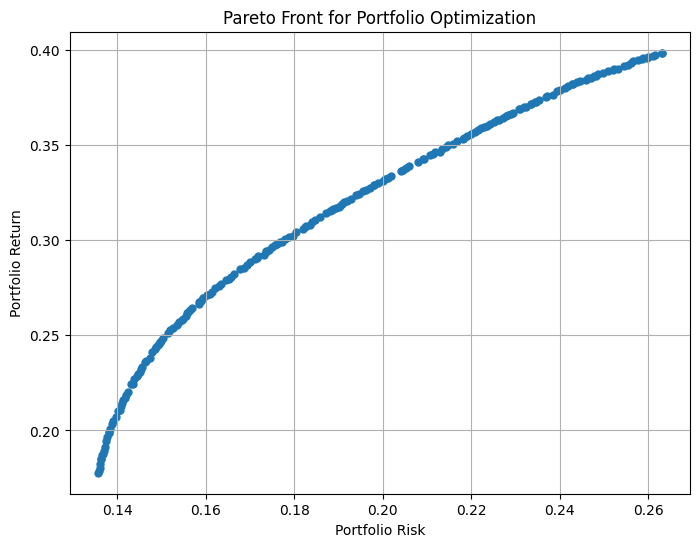

In [ ]:
# Visualize the Pareto front of portfolio risk and return.

plt.figure(figsize=(8, 6))
plt.scatter(portfolio_risks, portfolio_returns, s=25)
plt.xlabel("Portfolio Risk")
plt.ylabel("Portfolio Return")
plt.title("Pareto Front for Portfolio Optimization")
plt.grid(True)
plt.show()

Tambahin solusi eksak \\
Ganti ganti saham

Selected portfolio index: 6
Selected portfolio return: 0.284615828306479
Selected portfolio risk: 0.16762853919312817
Selected portfolio Sharpe ratio: 1.6978960126745928


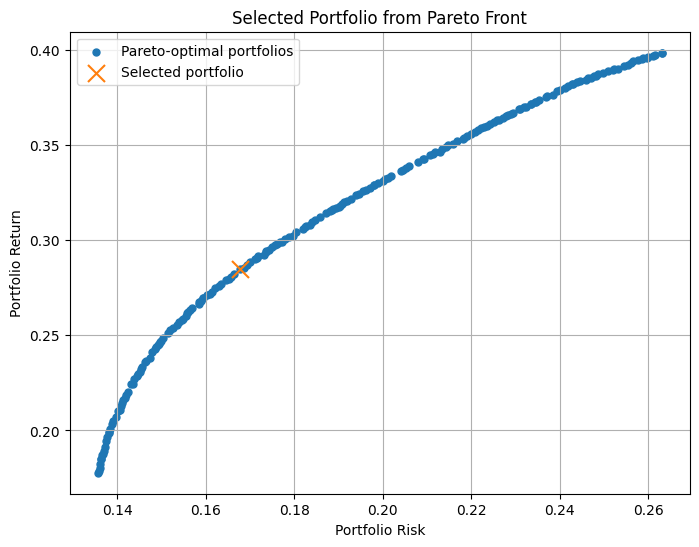

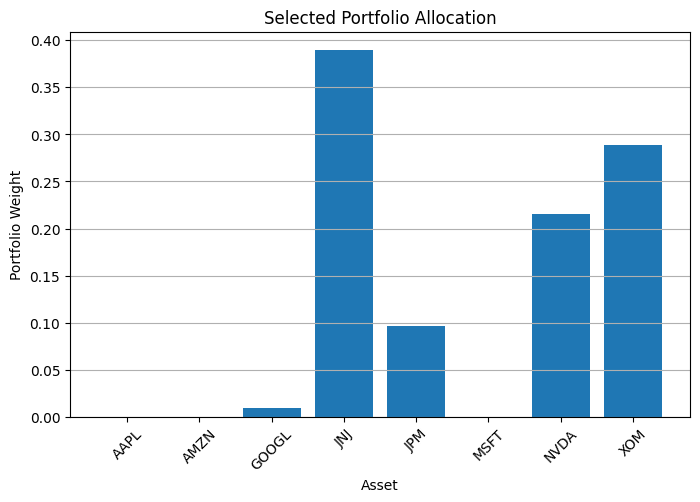

In [ ]:
# Select one portfolio using the maximum Sharpe ratio
best_idx = weights_df["Sharpe"].idxmax()

selected_portfolio = weights_df.loc[best_idx]

print("Selected portfolio index:", best_idx)
print("Selected portfolio return:", selected_portfolio["Return"])
print("Selected portfolio risk:", selected_portfolio["Risk"])
print("Selected portfolio Sharpe ratio:", selected_portfolio["Sharpe"])

selected_portfolio[available_tickers]

# Visualize the selected portfolio on the Pareto front
plt.figure(figsize=(8, 6))
plt.scatter(portfolio_risks, portfolio_returns, s=25, label="Pareto-optimal portfolios")
plt.scatter(
    selected_portfolio["Risk"],
    selected_portfolio["Return"],
    s=150,
    marker="x",
    label="Selected portfolio"
)
plt.xlabel("Portfolio Risk")
plt.ylabel("Portfolio Return")
plt.title("Selected Portfolio from Pareto Front")
plt.legend()
plt.grid(True)
plt.show()

# Visualize the asset allocation of the selected portfolio
plt.figure(figsize=(8, 5))
plt.bar(available_tickers, selected_portfolio[available_tickers])
plt.xlabel("Asset")
plt.ylabel("Portfolio Weight")
plt.title("Selected Portfolio Allocation")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

# 8. DTLZ1 Problem

The next benchmark problem is **DTLZ1**, which is one of the Deb-Thiele-Laumanns-Zitzler test problems for multi-objective optimization. Unlike ZDT1, which has two objective functions, DTLZ1 is commonly used for problems with three or more objectives.

In this example, DTLZ1 is solved as a **3-objective minimization problem** using NSGA-II.

The DTLZ1 problem can be written as:

$$
\min_{\mathbf{x}} \; \mathbf{F}(\mathbf{x})
=
[f_1(\mathbf{x}), f_2(\mathbf{x}), \ldots, f_M(\mathbf{x})]
$$

where:

$$
f_1(\mathbf{x})
=
\frac{1}{2}x_1x_2 \cdots x_{M-1}(1+g(\mathbf{x}))
$$

$$
f_2(\mathbf{x})
=
\frac{1}{2}x_1x_2 \cdots (1-x_{M-1})(1+g(\mathbf{x}))
$$

$$
\vdots
$$

$$
f_M(\mathbf{x})
=
\frac{1}{2}(1-x_1)(1+g(\mathbf{x}))
$$

The function $$g(\mathbf{x})$$ is defined using the last $$k=n-M+1$$ decision variables:

$$
g(\mathbf{x})
=
100
\left[
k
+
\sum_{i=M}^{n}
\left(
(x_i-0.5)^2
-
\cos(20\pi(x_i-0.5))
\right)
\right]
$$

with the variable bounds:

$$
0 \leq x_i \leq 1,
\qquad
i=1,2,\ldots,n
$$

For DTLZ1, the Pareto-optimal solution occurs when:

$$
x_i^* = 0.5,
\qquad
i=M,M+1,\ldots,n
$$

which gives:

$$
g(\mathbf{x}) = 0
$$

Therefore, the Pareto front of DTLZ1 is a linear hyper-plane:

$$
\sum_{m=1}^{M} f_m = \frac{1}{2},
\qquad
f_m \geq 0
$$

In this example, we use:

$$
M = 3
$$

and

$$
n = M+k-1 = 3+5-1 = 7
$$

Thus, the problem has **7 decision variables** and **3 objective functions**.

n_gen  |  n_eval  | n_nds  |      igd      |       gd     
     1 |      100 |     23 |  1.121323E+02 |  3.369911E+02
     2 |      200 |     30 |  1.121323E+02 |  3.344163E+02
     3 |      300 |     32 |  1.121323E+02 |  3.287036E+02
     4 |      400 |     30 |  6.389468E+01 |  3.354486E+02
     5 |      500 |     34 |  6.389468E+01 |  3.038832E+02
     6 |      600 |     39 |  6.389468E+01 |  3.036853E+02
     7 |      700 |     34 |  6.389468E+01 |  2.914910E+02
     8 |      800 |     34 |  4.663406E+01 |  3.210344E+02
     9 |      900 |     24 |  4.288084E+01 |  2.345853E+02
    10 |     1000 |     27 |  4.288084E+01 |  2.309824E+02
    11 |     1100 |     34 |  4.288084E+01 |  2.404441E+02
    12 |     1200 |     37 |  4.288084E+01 |  2.206430E+02
    13 |     1300 |     36 |  4.288084E+01 |  2.012441E+02
    14 |     1400 |     41 |  4.073915E+01 |  1.932885E+02
    15 |     1500 |     36 |  3.660073E+01 |  1.831091E+02
    16 |     1600 |     42 |  3.660073E+01 |  1.646678E+

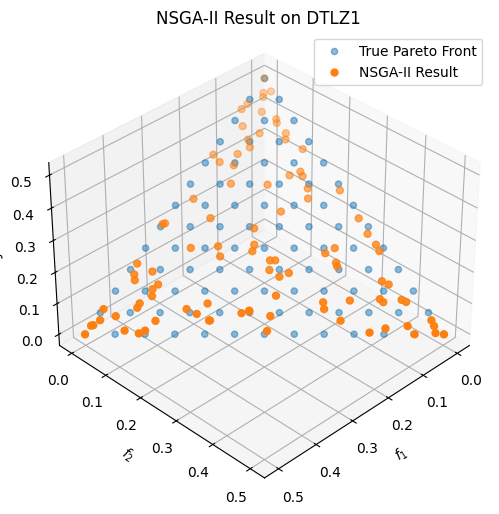

In [ ]:
from pymoo.problems import get_problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.util.ref_dirs import get_reference_directions

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


# Define DTLZ1 problem
n_obj = 3
k = 5
n_var = n_obj + k - 1

problem = get_problem("dtlz1", n_var=n_var, n_obj=n_obj)

# Define NSGA-II algorithm
algorithm = NSGA2(pop_size=100)

# Run optimization
res = minimize(
    problem,
    algorithm,
    termination=("n_gen", 500),
    seed=1,
    save_history=True,
    verbose=True
)

# Extract decision variables and objective values
X = res.X
F = res.F

# Generate the true Pareto front
# For DTLZ1, the Pareto front satisfies:
# f1 + f2 + f3 = 0.5
ref_dirs = get_reference_directions("das-dennis", n_obj, n_partitions=12)
pf = 0.5 * ref_dirs

# Plot result in 3D objective space
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    pf[:, 0],
    pf[:, 1],
    pf[:, 2],
    label="True Pareto Front",
    s=20,
    alpha=0.5
)

ax.scatter(
    F[:, 0],
    F[:, 1],
    F[:, 2],
    label="NSGA-II Result",
    s=25
)

# Better viewing angle for the DTLZ1 Pareto plane
ax.view_init(elev=35, azim=45)

ax.set_xlabel("$f_1$")
ax.set_ylabel("$f_2$")
ax.set_zlabel("$f_3$")
ax.set_title("NSGA-II Result on DTLZ1")
ax.legend()

plt.show()

## Solving DTLZ1 with NSGA - III

NSGA-III, or Non-dominated Sorting Genetic Algorithm III, is an extension of NSGA-II designed mainly for many-objective optimization problems.

The main idea of NSGA-III is very similar to NSGA-II: it still uses **non-dominated sorting** to rank solutions into Pareto fronts. The key difference is how diversity is maintained.

In **NSGA-II**, diversity is maintained using **crowding distance**.

In **NSGA-III**, diversity is maintained using **reference directions** instead of crowding distance.

Reference directions are predefined directions spread across the objective space. Each solution is associated with the closest reference direction, and solutions are selected so that the population remains well distributed along these directions.

For a solution with objective vector $\mathbf{F}(\mathbf{X})$ and a reference direction $\mathbf{z}$, the perpendicular distance to the reference direction can be written as:

$$
d_2(\mathbf{X}, \mathbf{z})
=
\left\|
\mathbf{F}(\mathbf{X})
-
\frac{\mathbf{z}^T \mathbf{F}(\mathbf{X})}{\|\mathbf{z}\|^2}
\mathbf{z}
\right\|_2
$$

where $d_2$ measures how far the solution is from the reference direction.

Therefore, the main difference can be summarized as:

$$
\text{NSGA-II: non-dominated sorting + crowding distance}
$$

$$
\text{NSGA-III: non-dominated sorting + reference directions}
$$

Because of this, NSGA-III is usually preferred when the number of objectives is large.

n_gen  |  n_eval  | n_nds  |      igd      |       gd     
     1 |      100 |     17 |  1.121323E+02 |  3.316181E+02
     2 |      200 |     17 |  1.121323E+02 |  3.358169E+02
     3 |      300 |     24 |  9.068896E+01 |  2.727471E+02
     4 |      400 |     24 |  6.674400E+01 |  2.348942E+02
     5 |      500 |     22 |  4.898137E+01 |  2.152244E+02
     6 |      600 |     18 |  4.898137E+01 |  2.122448E+02
     7 |      700 |     13 |  4.898137E+01 |  1.776576E+02
     8 |      800 |      9 |  4.898137E+01 |  1.170884E+02
     9 |      900 |     16 |  4.684094E+01 |  1.219584E+02
    10 |     1000 |     17 |  4.684094E+01 |  1.013894E+02
    11 |     1100 |     18 |  4.684094E+01 |  1.122771E+02
    12 |     1200 |     14 |  4.514152E+01 |  1.206958E+02
    13 |     1300 |     16 |  4.514152E+01 |  8.798805E+01
    14 |     1400 |     15 |  3.319968E+01 |  8.198536E+01
    15 |     1500 |     10 |  3.319968E+01 |  7.127309E+01
    16 |     1600 |      8 |  3.319968E+01 |  5.182336E+

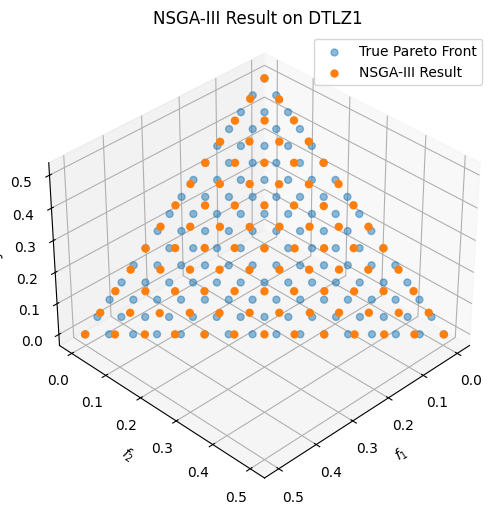

In [ ]:
from pymoo.problems import get_problem
from pymoo.algorithms.moo.nsga3 import NSGA3
from pymoo.optimize import minimize
from pymoo.util.ref_dirs import get_reference_directions

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


# Define DTLZ1 problem
n_obj = 3
k = 5
n_var = n_obj + k - 1

problem = get_problem("dtlz1", n_var=n_var, n_obj=n_obj)

# Generate the reference directions as done in the previous cell for plotting
ref_dirs = get_reference_directions("das-dennis", n_obj, n_partitions=12)

# Calling the algorithm
algorithm = NSGA3(pop_size=100, ref_dirs=ref_dirs)

# Run optimization
res = minimize(
    problem,
    algorithm,
    termination=("n_gen", 500),
    seed=1,
    save_history=True,
    verbose=True
)

# Extract decision variables and objective values
X = res.X
F = res.F

# Generate the true Pareto front
# For DTLZ1, the Pareto front satisfies:
# f1 + f2 + f3 = 0.5
pf = problem.pareto_front()

# Plot result in 3D objective space
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    pf[:, 0],
    pf[:, 1],
    pf[:, 2],
    label="True Pareto Front",
    s=25,
    alpha=0.5
)

ax.scatter(
    F[:, 0],
    F[:, 1],
    F[:, 2],
    label="NSGA-III Result",
    s=25,
    alpha = 1
)

# Better viewing angle for the DTLZ1 Pareto plane
ax.view_init(elev=35, azim=45)

ax.set_xlabel("$f_1$")
ax.set_ylabel("$f_2$")
ax.set_zlabel("$f_3$")
ax.set_title("NSGA-III Result on DTLZ1")
ax.legend()

plt.show()